### MODEL 3(b)

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [127]:
df = pd.read_csv('categorised_e11.csv')

In [128]:
a= list(df.columns)
print(a, np.size(a))

['Unnamed: 0', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41', 'c42', 'c43', 'c44', 'c45', 'c46', 'c47', 'c48', 'c49', 'c50', 'c55', 'c56', 'c57', 'c58', 'c59', 'c60', 'c61', 'c62', 'c63', 'c64', 'c65', 'c66', 'c67', 'c68', 'c69', 'c70', 'c71', 'c72', 'c73', 'c74', 'c75', 'c76', 'c77', 'c78', 'c79', 'c80', 'c81', 'c82', 'c83', 'c84', 'c85', 'c86', 'c87', 'c88', 'c89', 'c90', 'c91', 'c92', 'c93', 'c94', 'c95', 'c96', 'c97', 'c98', 'c99', 'c100', 'c101', 'c102', 'c103', 'c104', 'c105', 'c106', 'c107', 'c108', 'c109', 'c110', 'c111', 'c112', 'c113', 'c114', 'c115', 'c116', 'c117', 'c118', 'c119', 'c120', 'c121', 'c122', 'c123', 'c124', 'c133', 'c134', 'c135', 'c136', 'c137', 'c138', 'c139', 'c140', 'c141', 'c142', 'c143', 'c144', 'c145', 'c146', 'c147', 'c148', 'c149',

In [129]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=['c241', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32',
'c33', 'c39', 'c139', 'c142', 'c143', 'c155', 'c156', 'c157', 'c158', 'c160', 'c161', 'c162', 'c163'])
y = df['c241']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#k = 45
#selector = SelectKBest(f_regression, k=k)
#x_train_selected = selector.fit_transform(x_train, y_train)

#selected_features = X.columns[selector.get_support()]

#print('Selected Features:', selected_features)

In [130]:
feature_list = list(selected_features)

In [131]:
columns_to_remove = [] 
for i in range(len(feature_list)):
    for j in range(i+1, len(feature_list)):
        col1 = feature_list[i]
        col2 = feature_list[j] 
        corr_coefficient = df[col1].corr(df[col2])
        if abs(corr_coefficient) >= 0.71:
            columns_to_remove.append(col2)
feature_list = [col for col in feature_list if col not in columns_to_remove]
print(feature_list)

['c19', 'c48', 'c58', 'c60', 'c67']


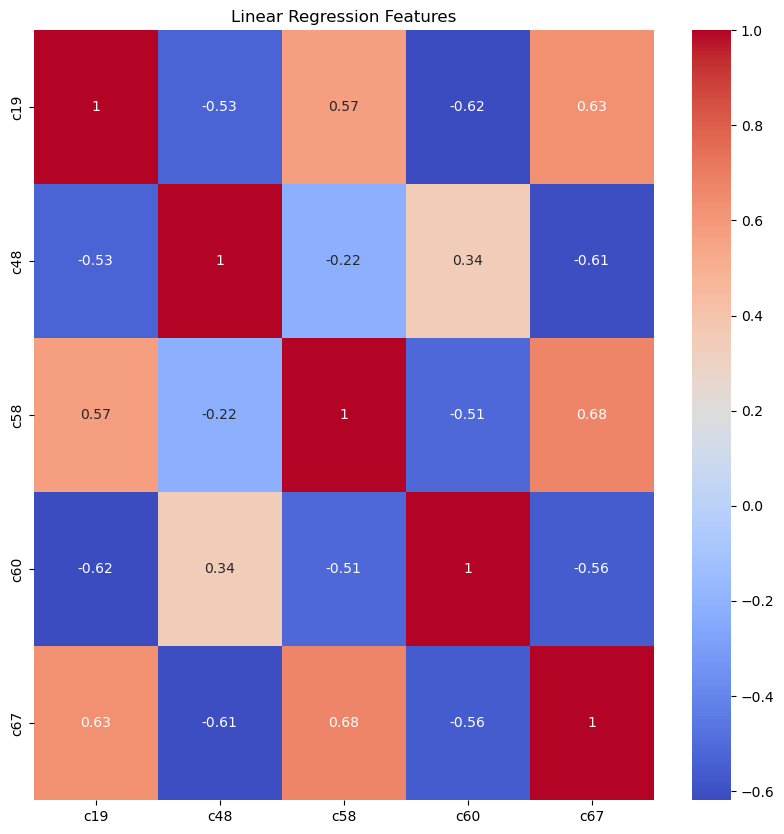

In [132]:
import seaborn as sns
correlation_matrix = df[feature_list].corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Linear Regression Features')
plt.show()

In [133]:
from sklearn.metrics import mean_squared_error, r2_score

X = df[feature_list]
X =  sm.add_constant(X)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
mlr_model = sm.OLS(y_train, x_train).fit()
print(mlr_model.summary())

y_pred = mlr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error for testing data: {mse}')
print(f'R-squared for testing data: {r2}')

                            OLS Regression Results                            
Dep. Variable:                   c241   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     463.6
Date:                Sun, 12 Nov 2023   Prob (F-statistic):          5.89e-221
Time:                        09:36:19   Log-Likelihood:                 1254.8
No. Observations:                 717   AIC:                            -2498.
Df Residuals:                     711   BIC:                            -2470.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2020      0.011    204.976      0.0

In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming you already have x_train as your design matrix with all the predictor variables

# Calculate VIF for each column in x_train
vif_data = pd.DataFrame()
vif_data["Variable"] = x_train.columns
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

# Display the VIF data
print(vif_data)

  Variable        VIF
0    const  46.419906
1      c19   2.312282
2      c48   2.086408
3      c58   2.360879
4      c60   1.770831
5      c67   3.438314


In [135]:
y_total_pred = mlr_model.predict(X)

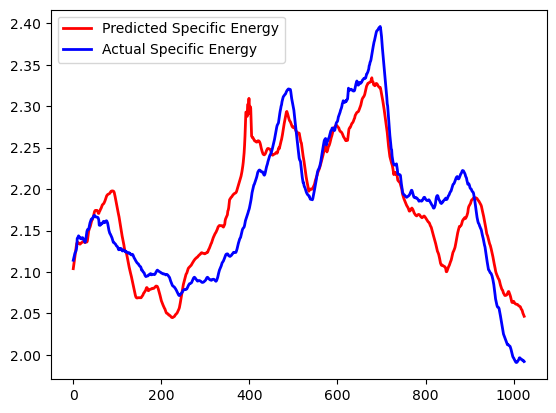

In [136]:
plt.plot(y_total_pred, color='red', linestyle='-', linewidth=2)
plt.plot(y, color='blue', linestyle='-', linewidth=2)
plt.legend(labels=['Predicted Specific Energy', 'Actual Specific Energy'])